# Visualization 2: Annotated Time Series — Gas Prices & World Events

Creates rich time series charts that tie gasoline price movements to major world events.

**Run this after `02_Data_Cleaning.ipynb` has completed.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

Path('outputs').mkdir(exist_ok=True)

# Load master dataset
master = pd.read_csv('data/processed/master_dataset.csv', index_col=0, parse_dates=True)
print(f' Loaded {len(master)} weeks of data')
print(f'   {master.index.min().date()} → {master.index.max().date()}')

✅ Loaded 1370 weeks of data
   2000-01-03 → 2026-03-30


## 1. Define World Events

Major events that impacted oil and gasoline markets.

In [2]:
# Categorized world events
events = [
    # Geopolitical / Wars
    {'date': '2001-09-11', 'label': '9/11 Attacks', 'category': 'Geopolitical', 'side': 'top'},
    {'date': '2003-03-20', 'label': 'Iraq War Begins', 'category': 'Geopolitical', 'side': 'bottom'},
    {'date': '2011-02-15', 'label': 'Arab Spring', 'category': 'Geopolitical', 'side': 'top'},
    {'date': '2012-07-01', 'label': 'Iran Sanctions', 'category': 'Geopolitical', 'side': 'bottom'},
    {'date': '2022-02-24', 'label': 'Russia Invades\nUkraine', 'category': 'Geopolitical', 'side': 'top'},
    {'date': '2023-10-07', 'label': 'Israel-Hamas\nWar', 'category': 'Geopolitical', 'side': 'bottom'},
    
    # OPEC / Supply Decisions
    {'date': '2008-09-10', 'label': 'OPEC Cuts\nProduction', 'category': 'OPEC/Supply', 'side': 'top'},
    {'date': '2014-11-27', 'label': 'OPEC Price\nWar Begins', 'category': 'OPEC/Supply', 'side': 'bottom'},
    {'date': '2016-11-30', 'label': 'OPEC Agrees\nto Cut', 'category': 'OPEC/Supply', 'side': 'top'},
    {'date': '2020-04-12', 'label': 'OPEC+ Historic\nCut (9.7M bpd)', 'category': 'OPEC/Supply', 'side': 'bottom'},
    
    # Economic
    {'date': '2007-12-01', 'label': 'Great Recession\nBegins', 'category': 'Economic', 'side': 'bottom'},
    {'date': '2008-07-14', 'label': 'Oil Peaks at\n$147/barrel', 'category': 'Economic', 'side': 'top'},
    {'date': '2020-03-11', 'label': 'COVID-19\nPandemic', 'category': 'Economic', 'side': 'top'},
    {'date': '2020-04-20', 'label': 'WTI Goes\nNegative', 'category': 'Economic', 'side': 'bottom'},
    {'date': '2022-06-13', 'label': 'Gas Hits\n$5/gallon', 'category': 'Economic', 'side': 'top'},
    
    # Natural Disasters
    {'date': '2005-08-29', 'label': 'Hurricane\nKatrina', 'category': 'Natural Disaster', 'side': 'top'},
    {'date': '2008-09-13', 'label': 'Hurricane\nIke', 'category': 'Natural Disaster', 'side': 'bottom'},
    {'date': '2017-08-25', 'label': 'Hurricane\nHarvey', 'category': 'Natural Disaster', 'side': 'top'},
    {'date': '2021-02-15', 'label': 'Texas Winter\nStorm Uri', 'category': 'Natural Disaster', 'side': 'bottom'},
]

events_df = pd.DataFrame(events)
events_df['date'] = pd.to_datetime(events_df['date'])

# Category colors
cat_colors = {
    'Geopolitical':     '#E74C3C',
    'OPEC/Supply':      '#E67E22',
    'Economic':         '#2E75B6',
    'Natural Disaster': '#27AE60',
}

print(f' {len(events)} events defined across {len(cat_colors)} categories')

✅ 19 events defined across 4 categories


## 2. Chart 1: Full Annotated Timeline — Crude Oil & Retail Gas

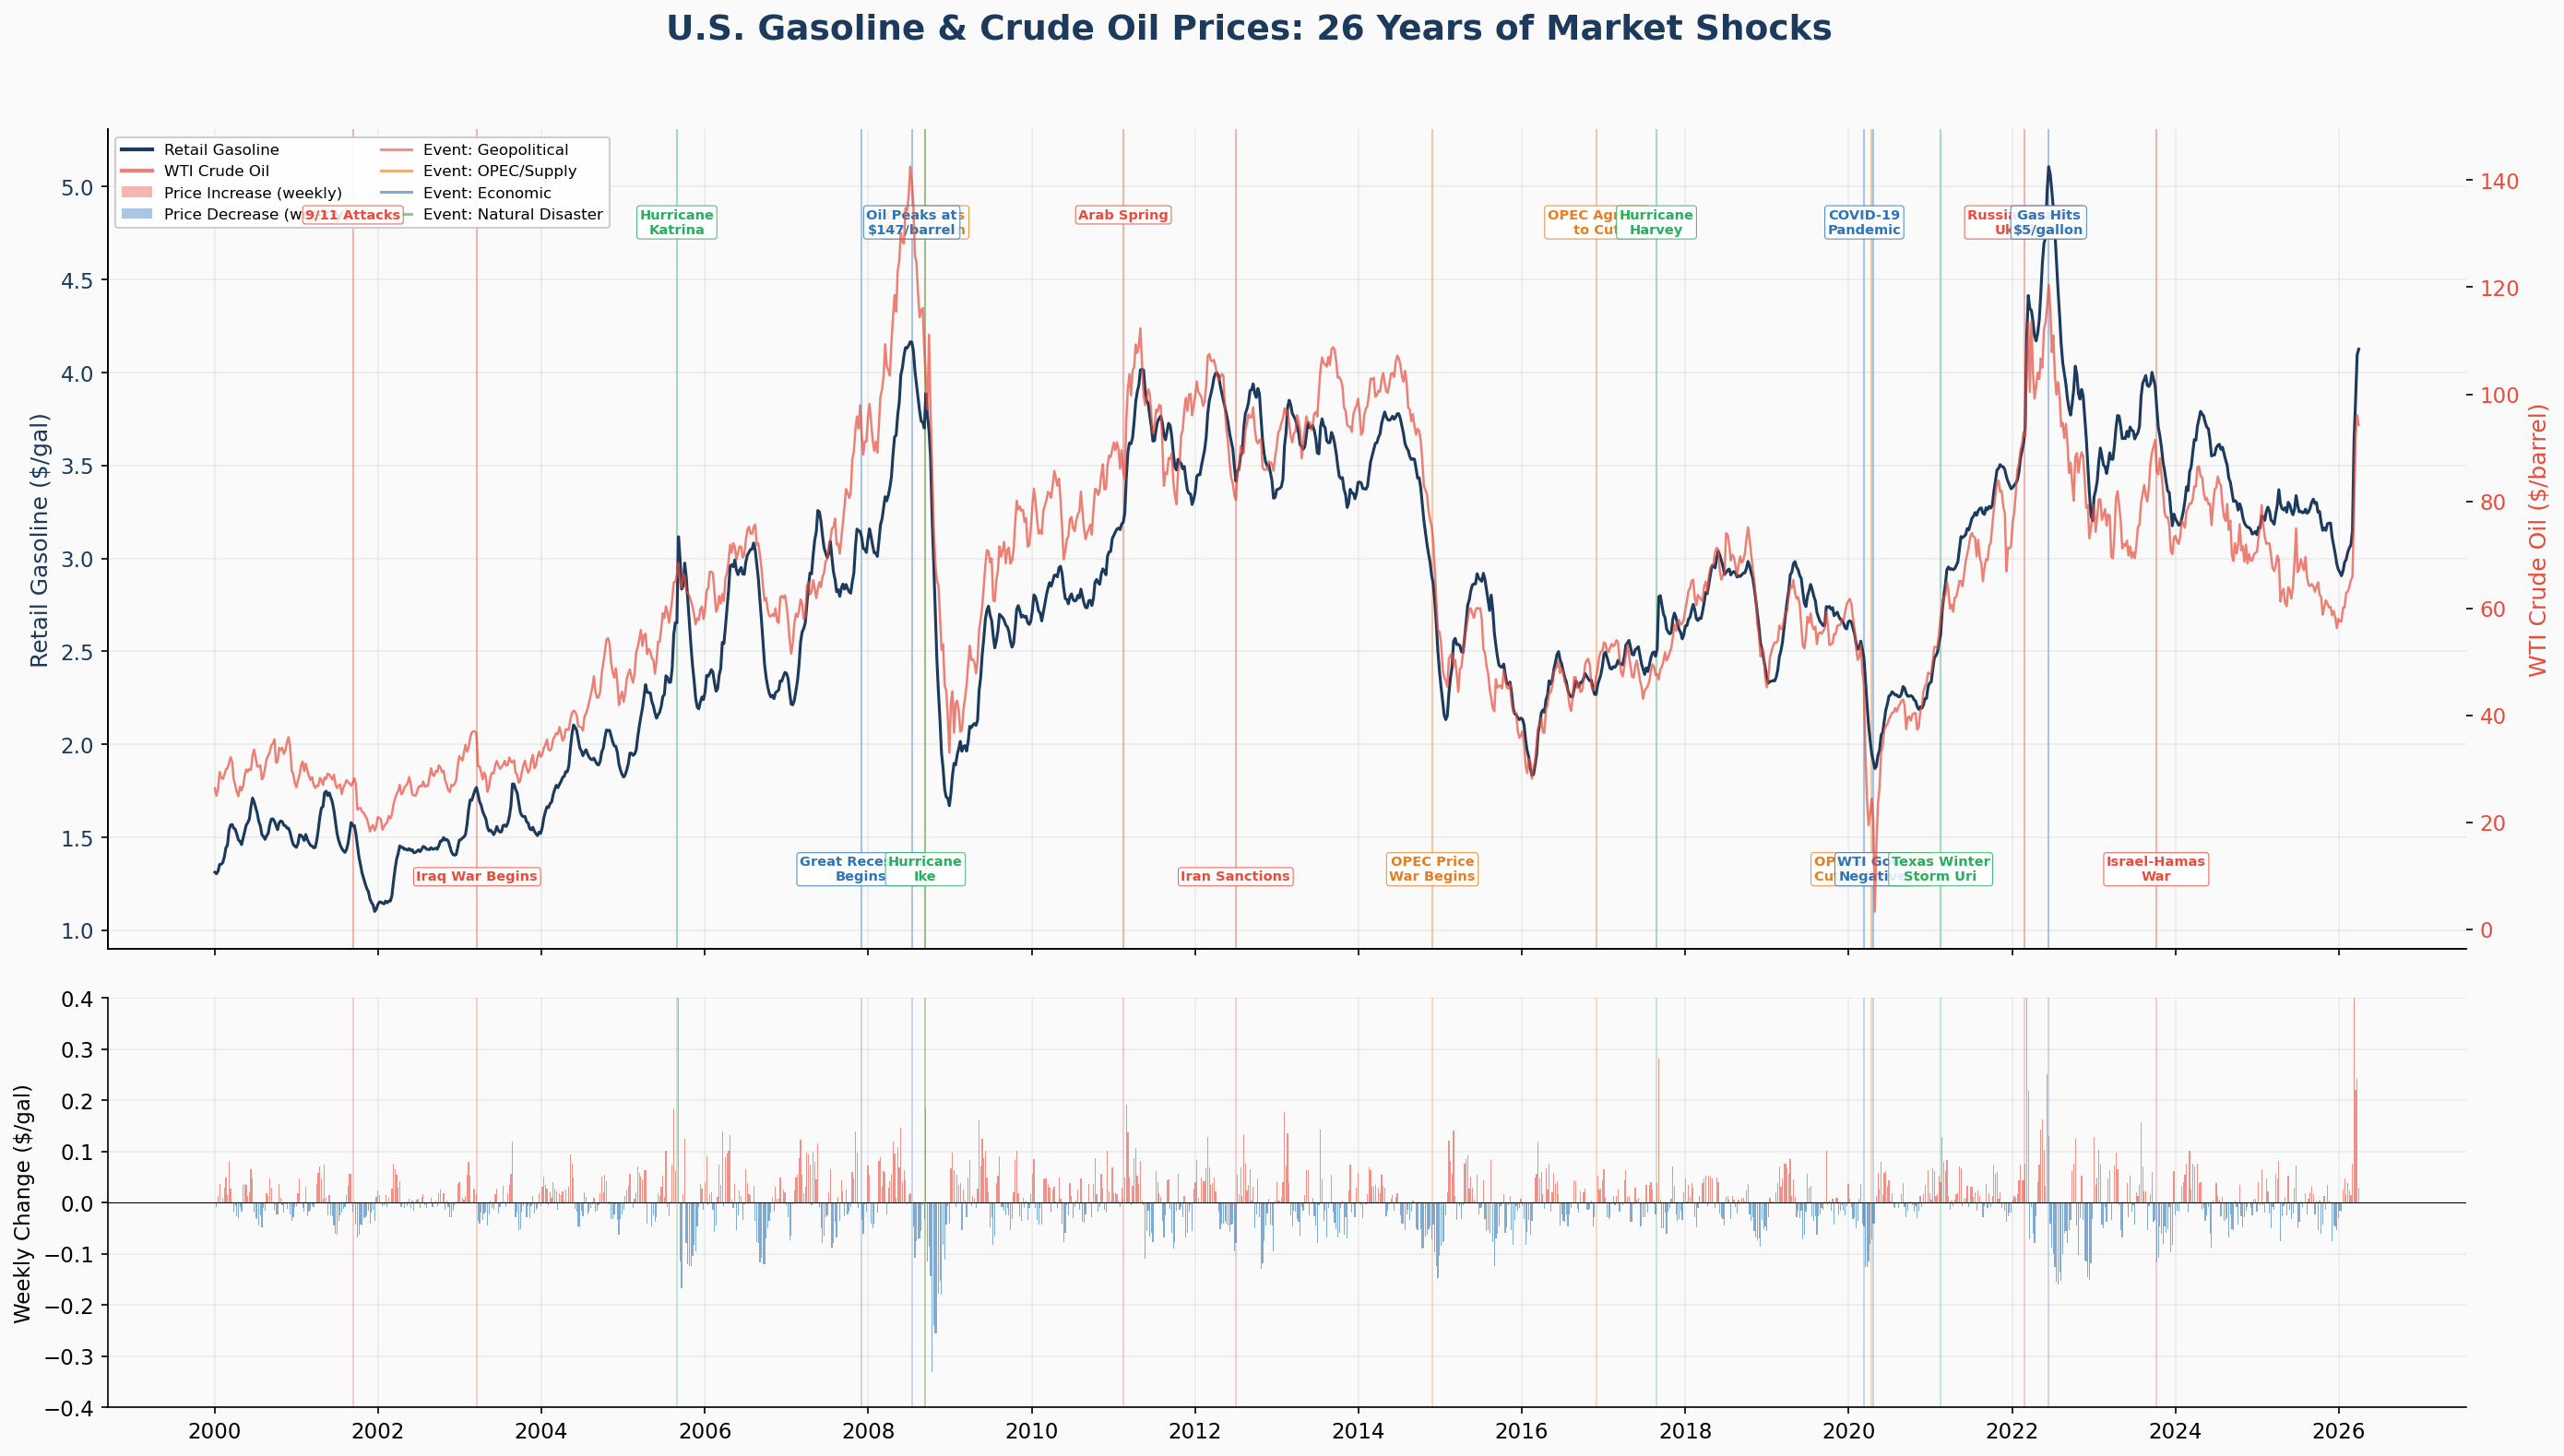


✅ Saved: outputs/timeline_annotated_full.png


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 12), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})
fig.patch.set_facecolor('#FAFAFA')
for a in [ax1, ax2]:
    a.set_facecolor('#FAFAFA')
    a.grid(True, alpha=0.2)

# ---- Top panel: Prices ----
# Retail gasoline
if 'retail_national' in master.columns:
    ax1.plot(master.index, master['retail_national'], color='#1B3A5C', linewidth=1.5, 
             label='Retail Gasoline ($/gal)', zorder=3)

# Crude oil on secondary axis
ax1b = ax1.twinx()
crude_col = 'wti_crude' if 'wti_crude' in master.columns else 'wti_crude_fred'
if crude_col in master.columns:
    ax1b.plot(master.index, master[crude_col], color='#E74C3C', linewidth=1.2, 
              alpha=0.7, label='WTI Crude Oil ($/bbl)', zorder=2)
ax1b.set_ylabel('WTI Crude Oil ($/barrel)', color='#E74C3C', fontsize=12)
ax1b.tick_params(axis='y', labelcolor='#E74C3C')
ax1b.spines['top'].set_visible(False)

ax1.set_ylabel('Retail Gasoline ($/gal)', color='#1B3A5C', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1B3A5C')

# ---- Annotate events on top panel ----
for _, event in events_df.iterrows():
    if event['date'] < master.index.min() or event['date'] > master.index.max():
        continue
    
    color = cat_colors[event['category']]
    
    # Vertical line
    ax1.axvline(event['date'], color=color, alpha=0.4, linewidth=1, linestyle='-', zorder=1)
    
    # Label position: top or bottom to avoid overlap
    if event['side'] == 'top':
        y_pos = ax1.get_ylim()[1] * 0.92
        va = 'top'
    else:
        y_pos = ax1.get_ylim()[0] + (ax1.get_ylim()[1] - ax1.get_ylim()[0]) * 0.08
        va = 'bottom'
    
    ax1.annotate(
        event['label'],
        xy=(event['date'], y_pos),
        fontsize=7,
        fontweight='bold',
        color=color,
        ha='center',
        va=va,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor=color, linewidth=0.5),
        zorder=10,
    )

# ---- Bottom panel: Weekly price change ----
if 'retail_national_chg' in master.columns:
    changes = master['retail_national_chg'].dropna()
    colors = ['#E74C3C' if x > 0 else '#2E75B6' for x in changes]
    ax2.bar(changes.index, changes.values, color=colors, alpha=0.6, width=5)
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.set_ylabel('Weekly Change ($/gal)', fontsize=11)
    ax2.set_ylim(-0.4, 0.4)
elif 'retail_national' in master.columns:
    changes = master['retail_national'].diff().dropna()
    colors = ['#E74C3C' if x > 0 else '#2E75B6' for x in changes]
    ax2.bar(changes.index, changes.values, color=colors, alpha=0.6, width=5)
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.set_ylabel('Weekly Change ($/gal)', fontsize=11)

# Event lines on bottom panel too
for _, event in events_df.iterrows():
    if event['date'] < master.index.min() or event['date'] > master.index.max():
        continue
    color = cat_colors[event['category']]
    ax2.axvline(event['date'], color=color, alpha=0.3, linewidth=0.8, linestyle='-')

# ---- Legend ----
legend_elements = [
    Line2D([0], [0], color='#1B3A5C', linewidth=2, label='Retail Gasoline'),
    Line2D([0], [0], color='#E74C3C', linewidth=2, alpha=0.7, label='WTI Crude Oil'),
    mpatches.Patch(facecolor='#E74C3C', alpha=0.4, label='Price Increase (weekly)'),
    mpatches.Patch(facecolor='#2E75B6', alpha=0.4, label='Price Decrease (weekly)'),
]
# Event category legend
for cat, color in cat_colors.items():
    legend_elements.append(Line2D([0], [0], color=color, linewidth=1.5, linestyle='-', alpha=0.6, label=f'Event: {cat}'))

ax1.legend(handles=legend_elements, loc='upper left', fontsize=8, framealpha=0.95, ncol=2)

# ---- Title ----
fig.suptitle(
    'U.S. Gasoline & Crude Oil Prices: 26 Years of Market Shocks',
    fontsize=18, fontweight='bold', color='#1B3A5C', y=0.95
)

ax2.set_xlabel('')
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.savefig('outputs/timeline_annotated_full.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('\n Saved: outputs/timeline_annotated_full.png')

## 3. Chart 2: Crisis Comparison — Normalized Price Shocks

Overlay major crises on the same chart. Week 0 = event date. Y-axis = % change from pre-event price.
This shows how fast prices reacted and how long recovery took for each crisis.

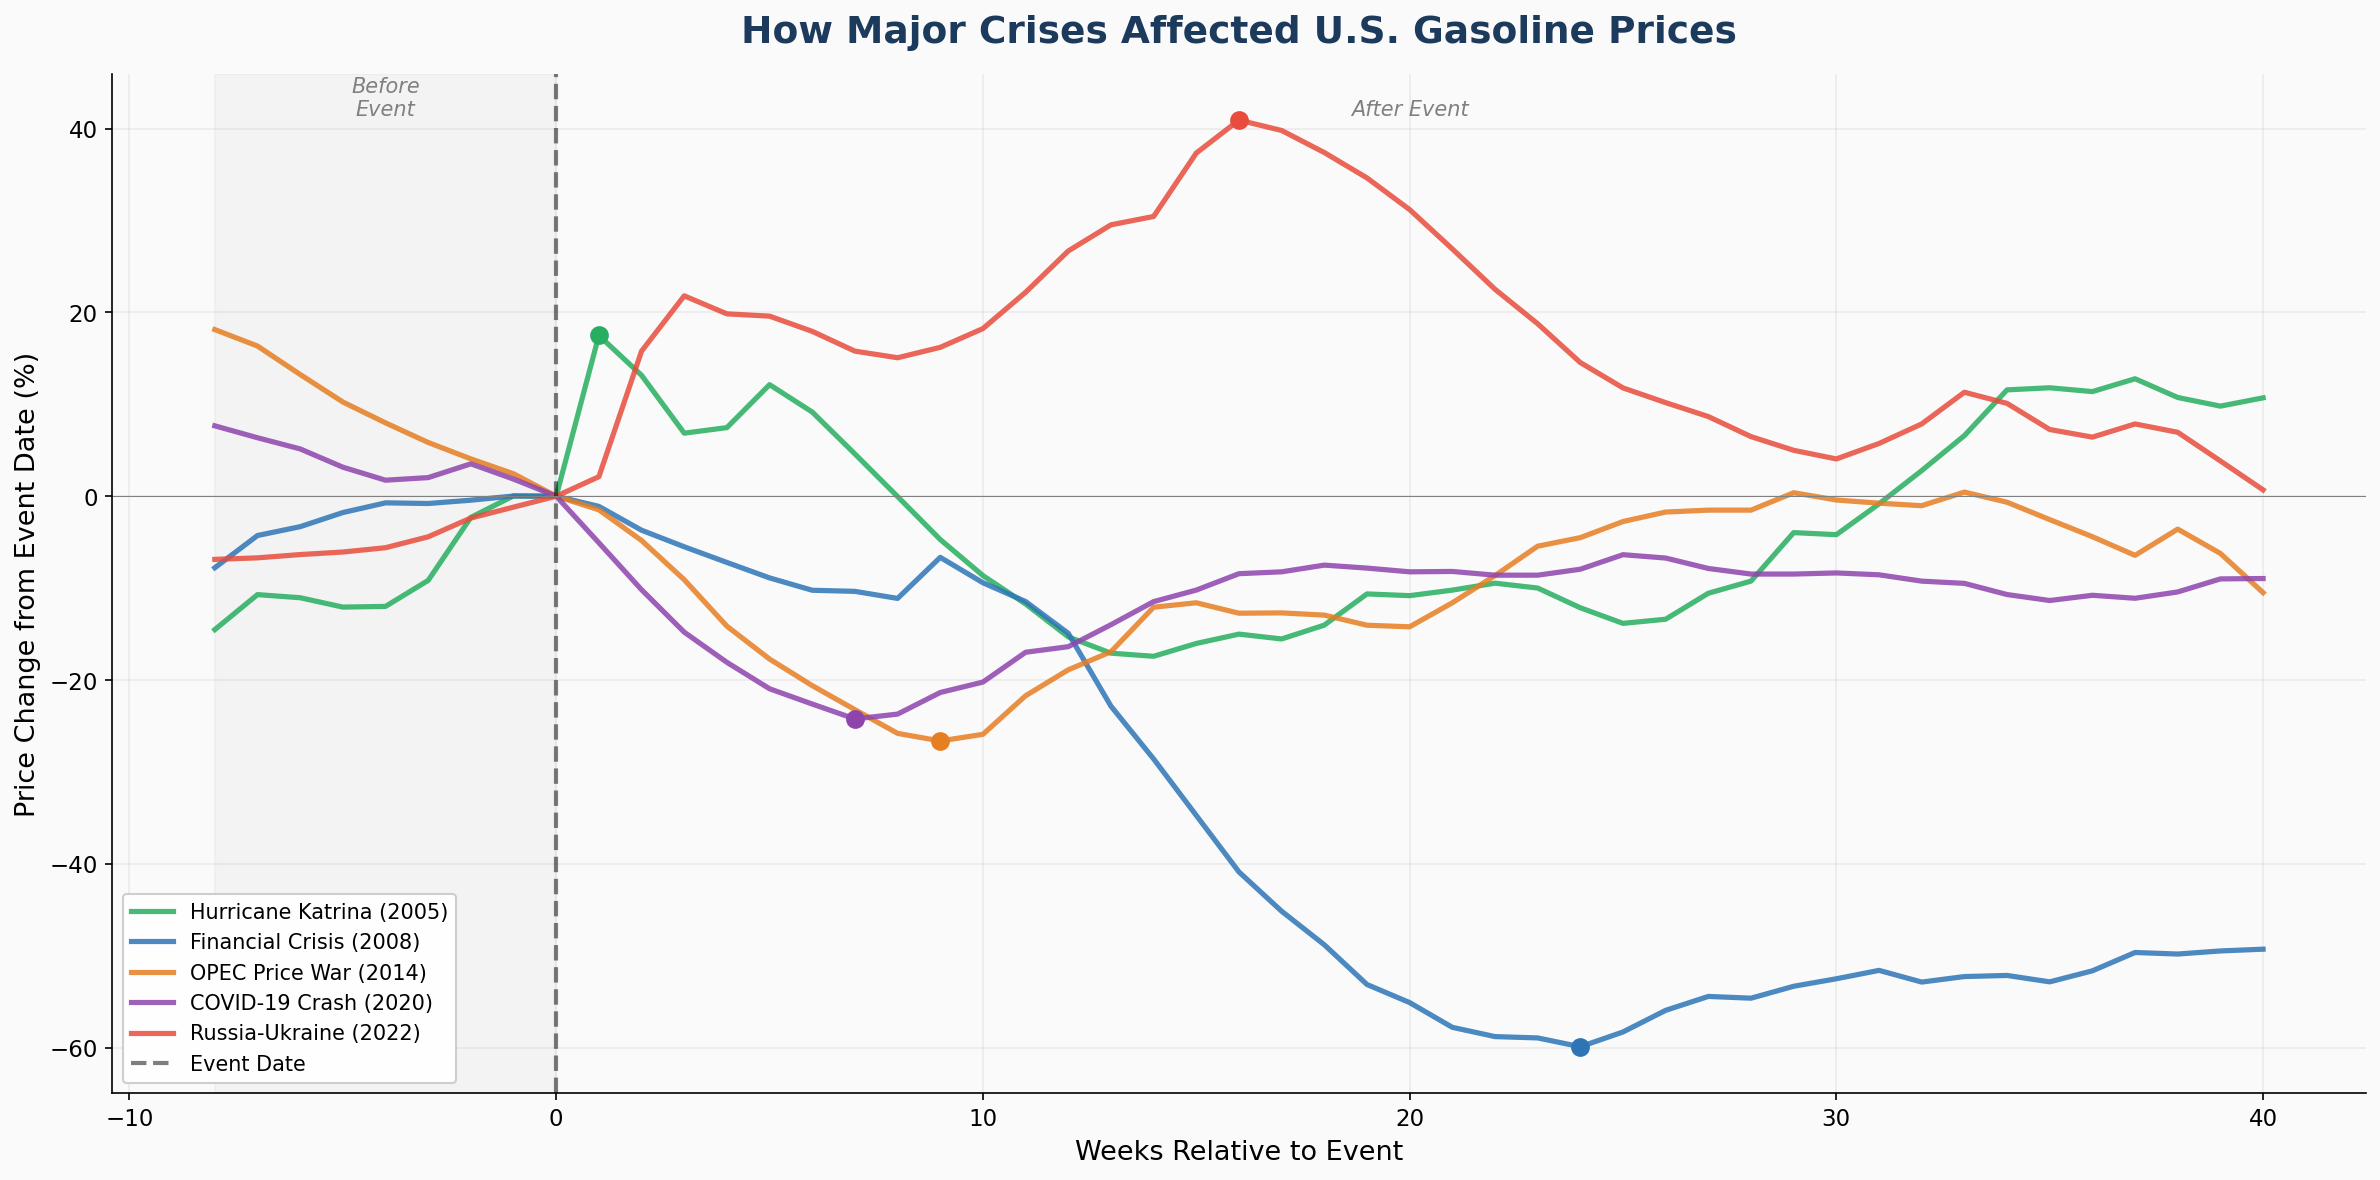


✅ Saved: outputs/crisis_comparison.png


In [4]:
# Select major crises to compare
crises = [
    {'name': 'Hurricane Katrina (2005)', 'date': '2005-08-29', 'color': '#27AE60', 'linestyle': '-'},
    {'name': 'Financial Crisis (2008)', 'date': '2008-07-14', 'color': '#2E75B6', 'linestyle': '-'},
    {'name': 'OPEC Price War (2014)', 'date': '2014-11-27', 'color': '#E67E22', 'linestyle': '-'},
    {'name': 'COVID-19 Crash (2020)', 'date': '2020-03-11', 'color': '#8E44AD', 'linestyle': '-'},
    {'name': 'Russia-Ukraine (2022)', 'date': '2022-02-24', 'color': '#E74C3C', 'linestyle': '-'},
]

price_col = 'retail_national' if 'retail_national' in master.columns else 'retail_gas_fred'
weeks_before = 8
weeks_after = 40

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, alpha=0.2)

for crisis in crises:
    event_date = pd.Timestamp(crisis['date'])
    
    # Find closest Monday in our data
    idx = master.index.get_indexer([event_date], method='nearest')[0]
    
    if idx < weeks_before or idx + weeks_after >= len(master):
        print(f'  Skipping {crisis["name"]} — not enough data around event')
        continue
    
    # Get price window around event
    window = master[price_col].iloc[idx - weeks_before : idx + weeks_after + 1].values
    
    if np.isnan(window).all():
        print(f'  Skipping {crisis["name"]} — all NaN')
        continue
    
    # Normalize: 0% = price at event date
    base_price = window[weeks_before]  # the event week
    if base_price == 0 or np.isnan(base_price):
        continue
    pct_change = ((window - base_price) / base_price) * 100
    
    weeks = range(-weeks_before, weeks_after + 1)
    
    ax.plot(weeks, pct_change, color=crisis['color'], linewidth=2.5, 
            linestyle=crisis['linestyle'], label=crisis['name'], alpha=0.85)
    
    # Mark the peak/trough
    max_idx = np.nanargmax(np.abs(pct_change[weeks_before:]))
    ax.plot(max_idx, pct_change[weeks_before + max_idx], 'o', 
            color=crisis['color'], markersize=8, zorder=5)

# Event line at week 0
ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.5, label='Event Date')
ax.axhline(0, color='gray', linewidth=0.5)

# Shading
ax.axvspan(-weeks_before, 0, alpha=0.05, color='gray')
ax.text(-weeks_before/2, ax.get_ylim()[1] * 0.9, 'Before\nEvent', 
        ha='center', fontsize=10, color='gray', fontstyle='italic')
ax.text(weeks_after/2, ax.get_ylim()[1] * 0.9, 'After Event', 
        ha='center', fontsize=10, color='gray', fontstyle='italic')

ax.set_xlabel('Weeks Relative to Event', fontsize=13)
ax.set_ylabel('Price Change from Event Date (%)', fontsize=13)
ax.set_title('How Major Crises Affected U.S. Gasoline Prices',
             fontsize=18, fontweight='bold', color='#1B3A5C', pad=15)

ax.legend(fontsize=10, framealpha=0.95, loc='lower left')

plt.tight_layout()
plt.savefig('outputs/crisis_comparison.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('\n Saved: outputs/crisis_comparison.png')

## 4. Chart 3: Zoomed Crisis Windows

Close-up panels of 3 major events showing the detail of how prices moved.

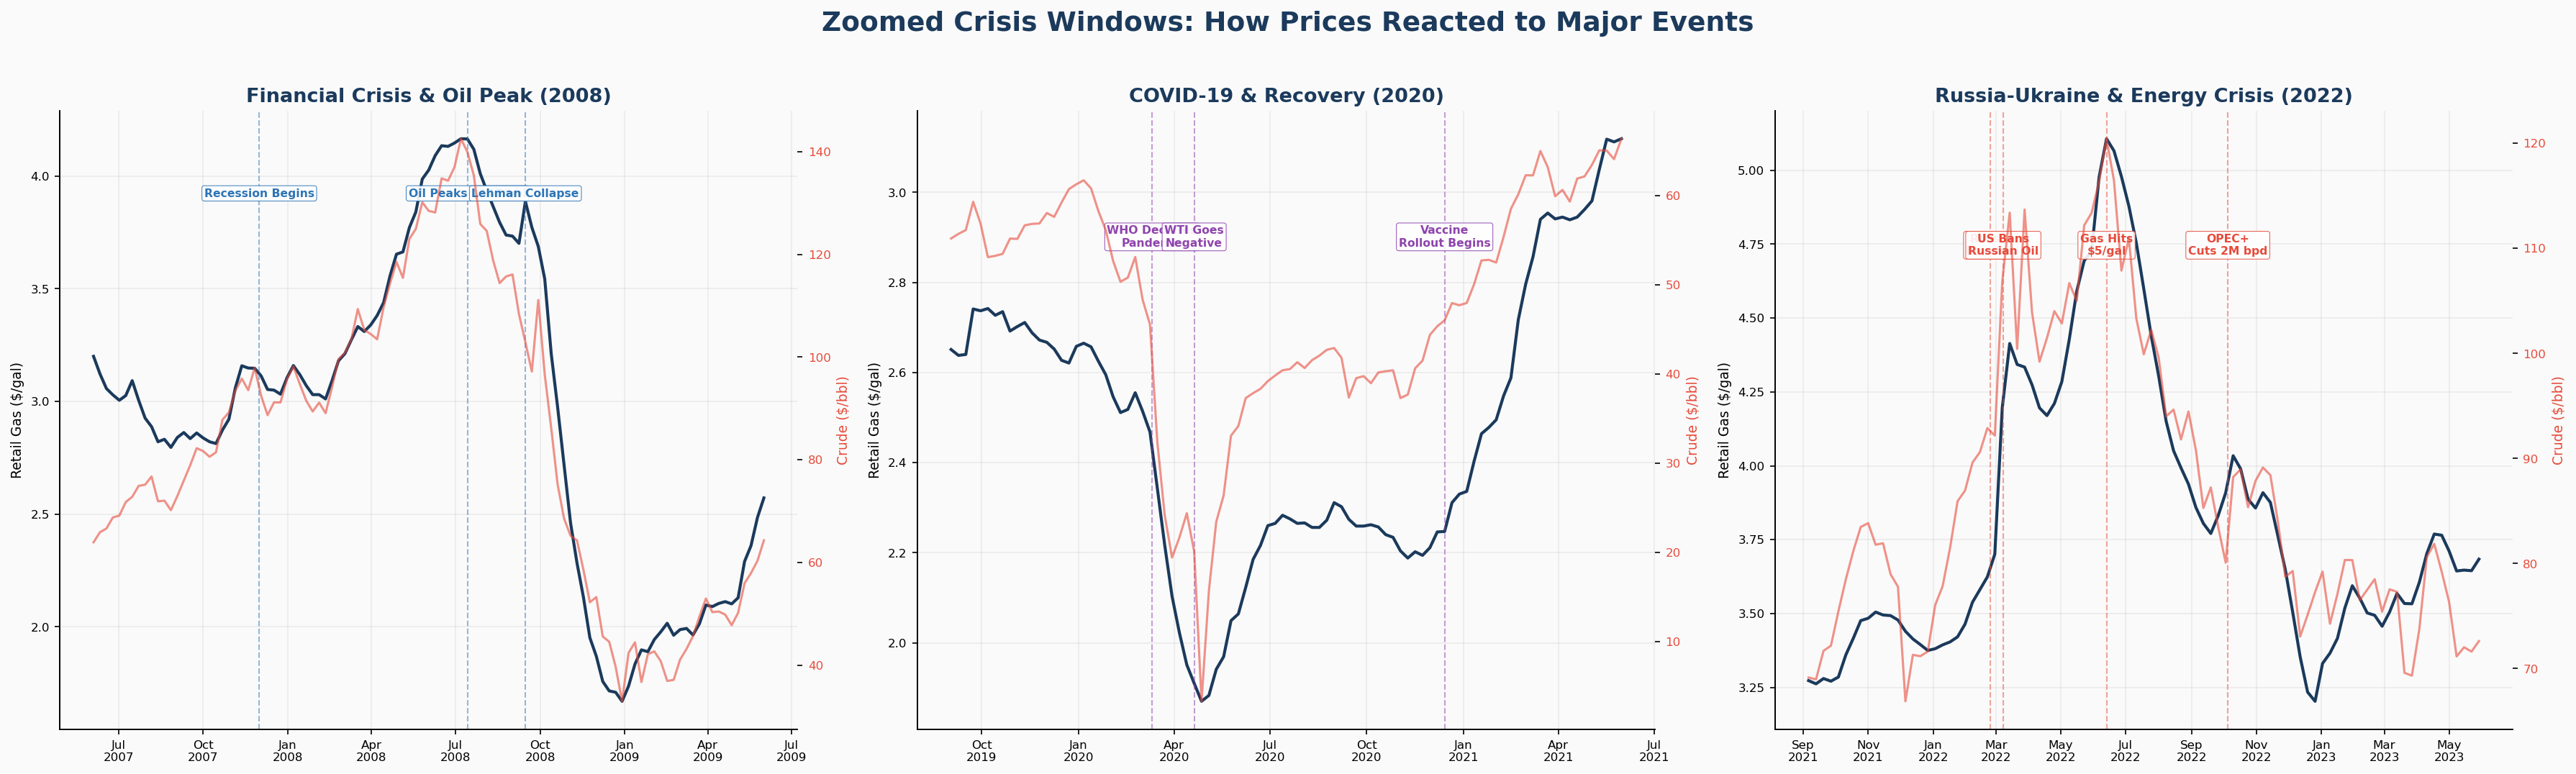


✅ Saved: outputs/crisis_zoom_panels.png


In [5]:
zoom_events = [
    {
        'title': 'Financial Crisis & Oil Peak (2008)',
        'start': '2007-06-01', 'end': '2009-06-01',
        'annotations': [
            ('2007-12-01', 'Recession Begins'),
            ('2008-07-14', 'Oil Peaks $147/bbl'),
            ('2008-09-15', 'Lehman Collapse'),
        ],
        'color': '#2E75B6',
    },
    {
        'title': 'COVID-19 & Recovery (2020)',
        'start': '2019-09-01', 'end': '2021-06-01',
        'annotations': [
            ('2020-03-11', 'WHO Declares\nPandemic'),
            ('2020-04-20', 'WTI Goes\nNegative'),
            ('2020-12-14', 'Vaccine\nRollout Begins'),
        ],
        'color': '#8E44AD',
    },
    {
        'title': 'Russia-Ukraine & Energy Crisis (2022)',
        'start': '2021-09-01', 'end': '2023-06-01',
        'annotations': [
            ('2022-02-24', 'Russia\nInvades'),
            ('2022-03-08', 'US Bans\nRussian Oil'),
            ('2022-06-13', 'Gas Hits\n$5/gal'),
            ('2022-10-05', 'OPEC+\nCuts 2M bpd'),
        ],
        'color': '#E74C3C',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Zoomed Crisis Windows: How Prices Reacted to Major Events',
             fontsize=18, fontweight='bold', color='#1B3A5C', y=1.02)

price_col = 'retail_national' if 'retail_national' in master.columns else 'retail_gas_fred'
crude_col = 'wti_crude' if 'wti_crude' in master.columns else 'wti_crude_fred'

for ax, event in zip(axes, zoom_events):
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, alpha=0.2)
    
    window = master.loc[event['start']:event['end']]
    
    if price_col in window.columns:
        ax.plot(window.index, window[price_col], color='#1B3A5C', linewidth=2, label='Retail Gas')
    
    # Crude on secondary axis
    if crude_col in window.columns:
        ax2 = ax.twinx()
        ax2.plot(window.index, window[crude_col], color='#E74C3C', linewidth=1.5, alpha=0.6, label='WTI Crude')
        ax2.set_ylabel('Crude ($/bbl)', color='#E74C3C', fontsize=9)
        ax2.tick_params(axis='y', labelcolor='#E74C3C', labelsize=8)
        ax2.spines['top'].set_visible(False)
    
    # Annotations
    for ann_date, ann_label in event['annotations']:
        ann_dt = pd.Timestamp(ann_date)
        ax.axvline(ann_dt, color=event['color'], alpha=0.5, linewidth=1, linestyle='--')
        
        # Alternate top/bottom
        y_pos = ax.get_ylim()[1] * 0.92
        ax.annotate(
            ann_label,
            xy=(ann_dt, y_pos),
            fontsize=7.5,
            fontweight='bold',
            color=event['color'],
            ha='center',
            va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, edgecolor=event['color'], linewidth=0.5),
        )
    
    ax.set_title(event['title'], fontsize=13, fontweight='bold', color='#1B3A5C')
    ax.set_ylabel('Retail Gas ($/gal)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('outputs/crisis_zoom_panels.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('\n Saved: outputs/crisis_zoom_panels.png')

## 5. Chart 4: Seasonal Price Pattern

Average gas price by week of year — reveals the summer blend premium.

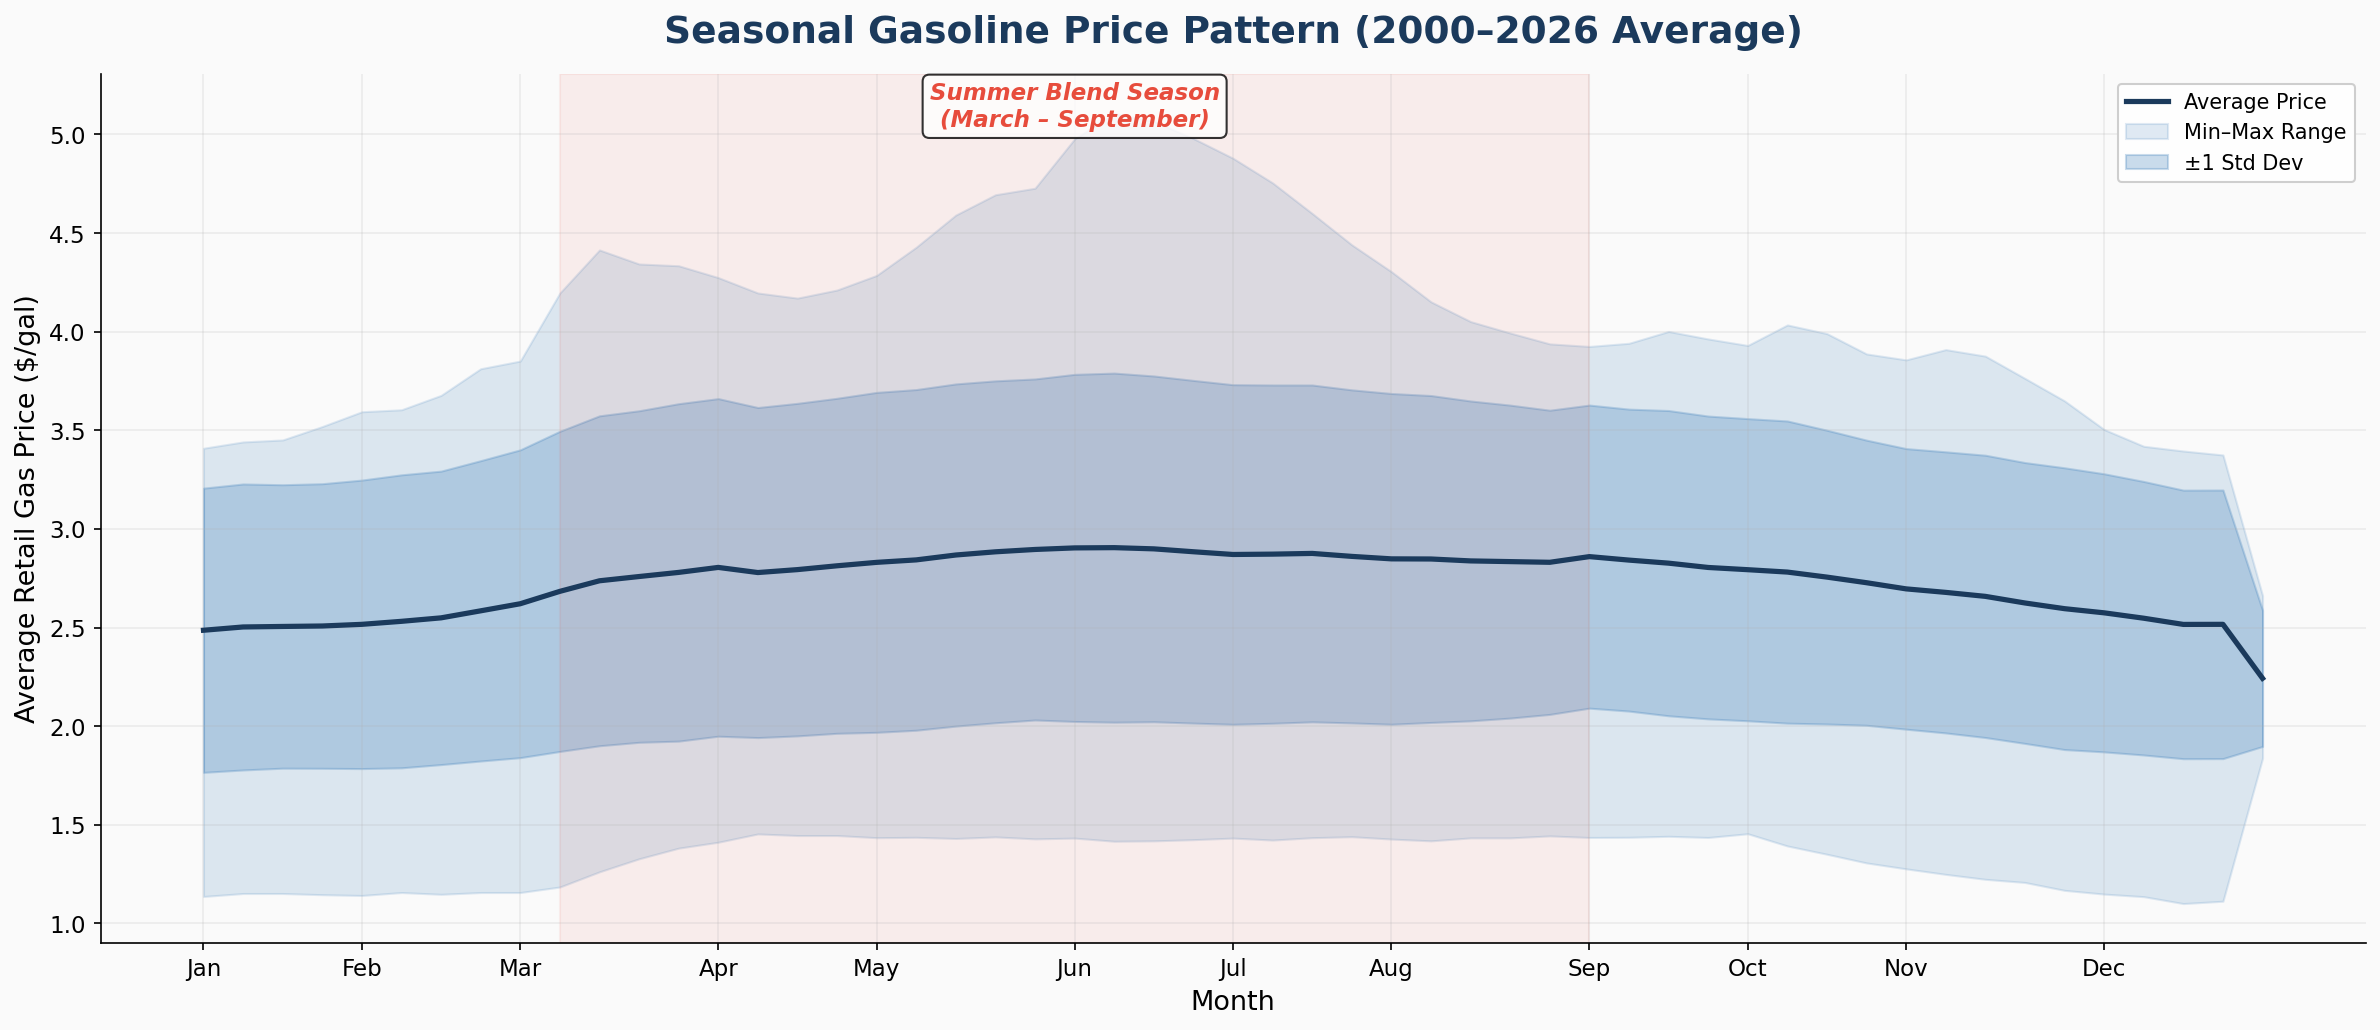


✅ Saved: outputs/seasonal_pattern.png


In [6]:
price_col = 'retail_national' if 'retail_national' in master.columns else 'retail_gas_fred'

if price_col in master.columns:
    temp = master[[price_col]].copy()
    temp['week'] = temp.index.isocalendar().week.astype(int)
    temp['year'] = temp.index.year
    
    # Calculate weekly change from January baseline for each year
    seasonal = temp.groupby('week')[price_col].agg(['mean', 'std', 'min', 'max'])
    
    # Normalize: show as % above/below annual average
    annual_avg = temp[price_col].mean()
    seasonal['pct_from_avg'] = ((seasonal['mean'] - annual_avg) / annual_avg) * 100
    
    fig, ax = plt.subplots(figsize=(16, 7))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, alpha=0.2)
    
    # Plot average with confidence band
    ax.plot(seasonal.index, seasonal['mean'], color='#1B3A5C', linewidth=2.5, label='Average Price', zorder=3)
    ax.fill_between(seasonal.index, seasonal['min'], seasonal['max'], alpha=0.15, color='#2E75B6', label='Min–Max Range')
    ax.fill_between(seasonal.index, seasonal['mean'] - seasonal['std'], seasonal['mean'] + seasonal['std'], 
                    alpha=0.25, color='#2E75B6', label='±1 Std Dev')
    
    # Highlight summer blend season
    ax.axvspan(10, 36, alpha=0.08, color='#E74C3C')
    ax.text(23, ax.get_ylim()[1] * 0.95, 'Summer Blend Season\n(March – September)',
            ha='center', fontsize=11, color='#E74C3C', fontstyle='italic', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Month labels
    month_weeks = [1, 5, 9, 14, 18, 23, 27, 31, 36, 40, 44, 49]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ax.set_xticks(month_weeks)
    ax.set_xticklabels(month_names)
    
    ax.set_xlabel('Month', fontsize=13)
    ax.set_ylabel('Average Retail Gas Price ($/gal)', fontsize=13)
    ax.set_title('Seasonal Gasoline Price Pattern (2000–2026 Average)',
                 fontsize=18, fontweight='bold', color='#1B3A5C', pad=15)
    ax.legend(fontsize=10, framealpha=0.95)
    
    plt.tight_layout()
    plt.savefig('outputs/seasonal_pattern.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
    plt.show()
    print('\n Saved: outputs/seasonal_pattern.png')
else:
    print('No retail price column found')

## 6. Chart 5: Rockets & Feathers — Asymmetry Visualization

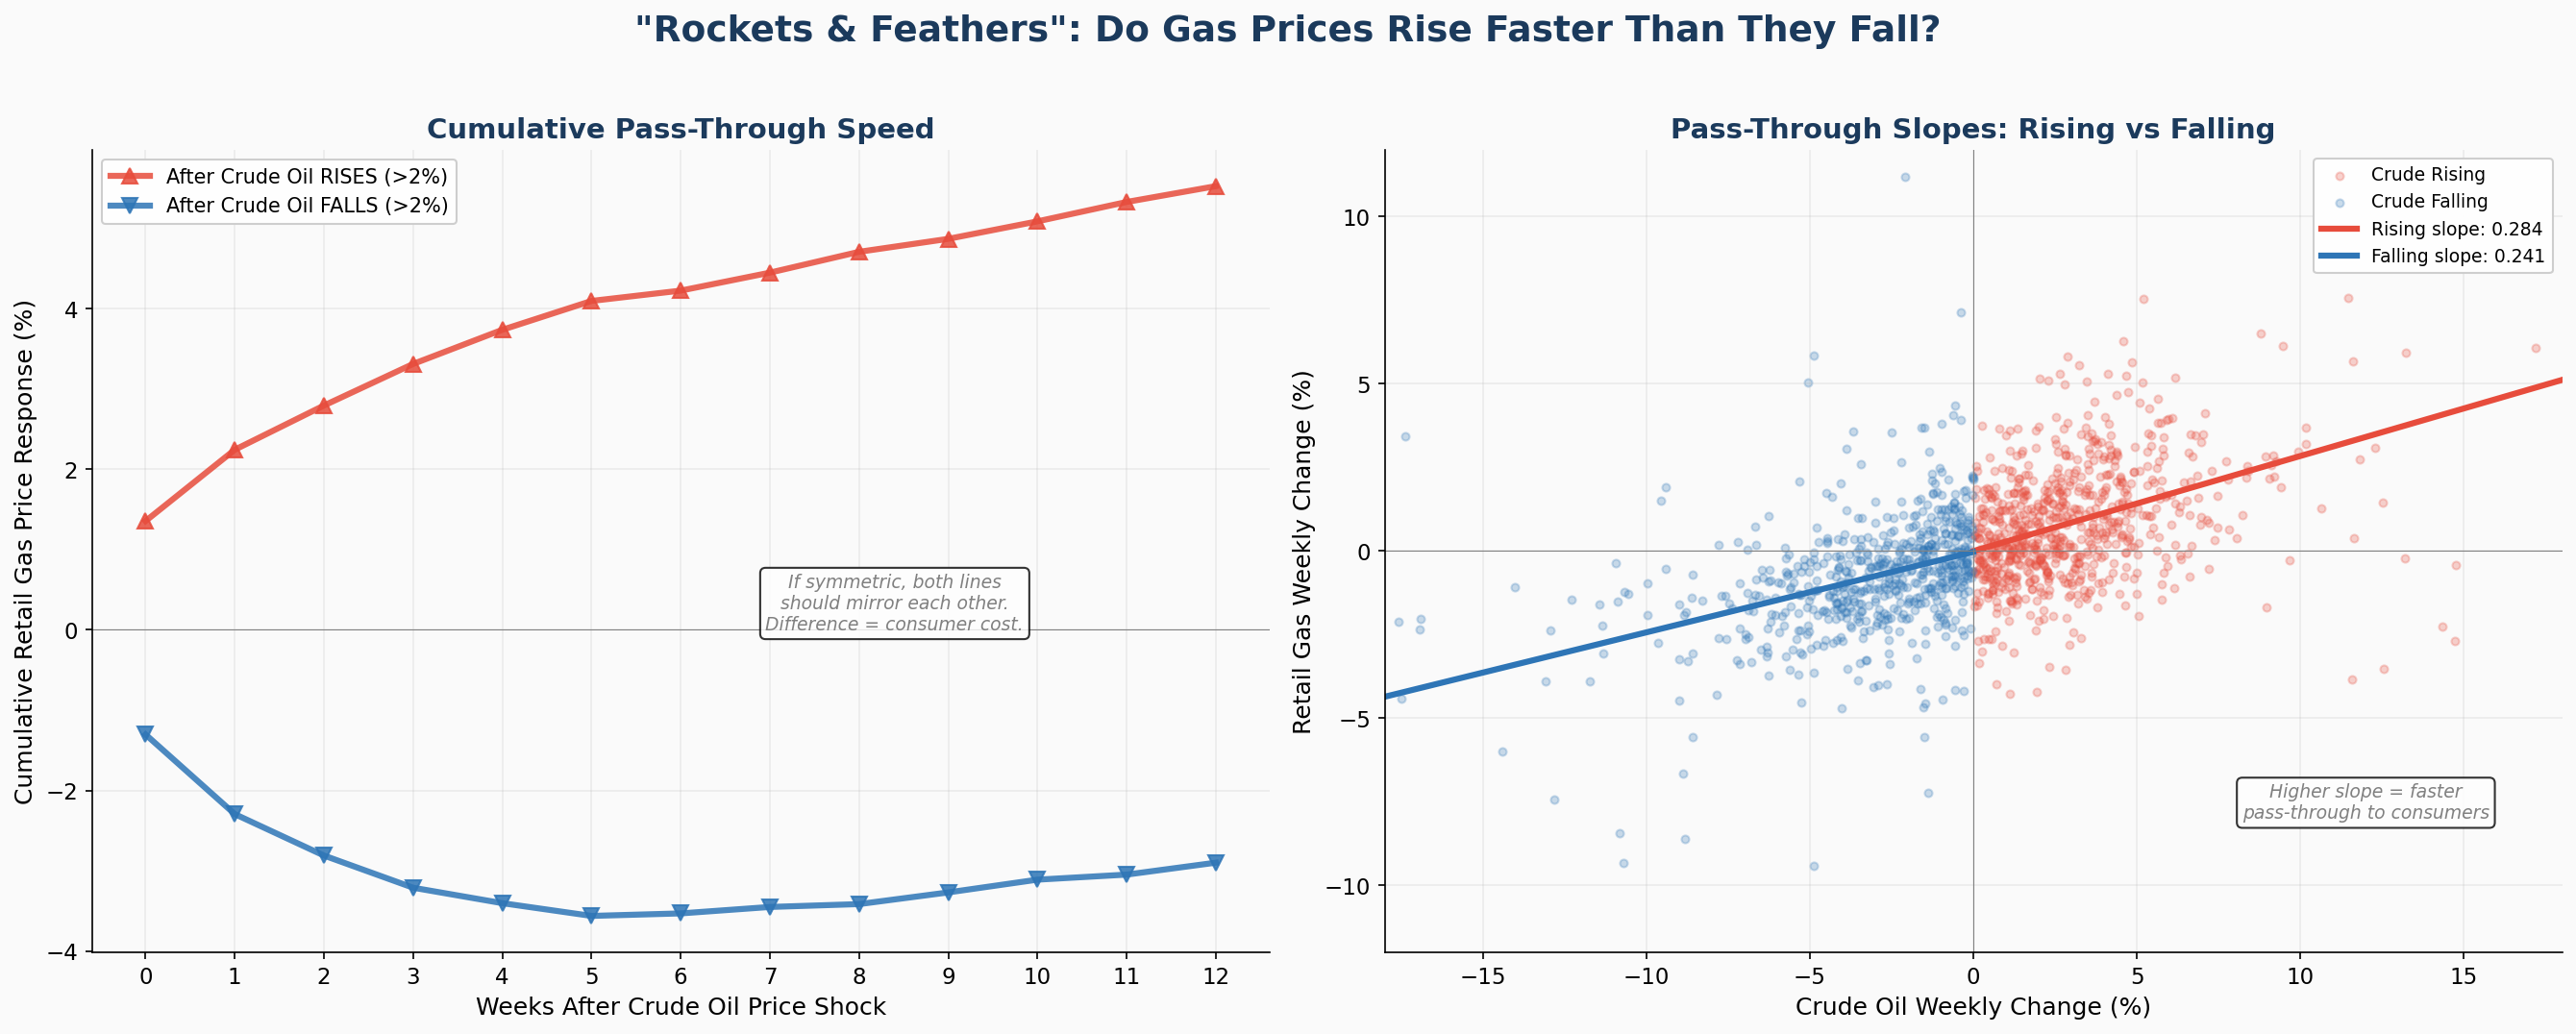


✅ Saved: outputs/rockets_feathers.png


In [10]:
price_col = 'retail_national' if 'retail_national' in master.columns else 'retail_gas_fred'
crude_col = 'wti_crude' if 'wti_crude' in master.columns else 'wti_crude_fred'

if price_col in master.columns and crude_col in master.columns:
    crude_chg = master[crude_col].pct_change()
    retail_chg = master[price_col].pct_change()
    
    rising = crude_chg > 0.02   # crude rose more than 2%
    falling = crude_chg < -0.02  # crude fell more than 2%
    
    max_weeks = 12
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.patch.set_facecolor('#FAFAFA')
    fig.suptitle('"Rockets & Feathers": Do Gas Prices Rise Faster Than They Fall?',
                 fontsize=18, fontweight='bold', color='#1B3A5C', y=1.02)
    
    # ---- Left: Cumulative response ----
    ax = axes[0]
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, alpha=0.2)
    
    for direction, mask, color, label, marker in [
        ('rise', rising, '#E74C3C', 'After Crude Oil RISES (>2%)', '^'),
        ('fall', falling, '#2E75B6', 'After Crude Oil FALLS (>2%)', 'v'),
    ]:
        responses = []
        for lag in range(max_weeks + 1):
            shifted = retail_chg.shift(-lag)
            common = crude_chg[mask].dropna().index.intersection(shifted.dropna().index)
            if len(common) > 20:
                responses.append(shifted.loc[common].mean() * 100)
            else:
                responses.append(np.nan)
        
        cumulative = np.nancumsum(responses)
        ax.plot(range(max_weeks + 1), cumulative, color=color, linewidth=3, 
                marker=marker, markersize=8, label=label, alpha=0.85)
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('Weeks After Crude Oil Price Shock', fontsize=12)
    ax.set_ylabel('Cumulative Retail Gas Price Response (%)', fontsize=12)
    ax.set_title('Cumulative Pass-Through Speed', fontsize=14, fontweight='bold', color='#1B3A5C')
    ax.legend(fontsize=10, framealpha=0.95)
    ax.set_xticks(range(max_weeks + 1))
    
    # Add insight annotation
    ax.annotate(
        'If symmetric, both lines\nshould mirror each other.\nDifference = consumer cost.',
        xy=(max_weeks * 0.7, 0),
        fontsize=9,
        color='gray',
        fontstyle='italic',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
    )
    
 # ============================================================
# REPLACE the scatter plot section in the Rockets & Feathers cell
# (the right panel part, starting from "# ---- Right: Scatter...")
# Replace EVERYTHING from "# ---- Right: Scatter" to the end of the cell with this:
# ============================================================

    # ---- Right: Scatter with separate regression lines ----
    ax = axes[1]
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, alpha=0.2)
    
    from scipy import stats
    
    c_chg = crude_chg.dropna() * 100
    r_chg = retail_chg.dropna() * 100
    common = c_chg.index.intersection(r_chg.index)
    c_common = c_chg.loc[common]
    r_common = r_chg.loc[common]
    
    # FILTER OUT EXTREME OUTLIERS (keep only -20% to +20% crude changes)
    normal_mask = (c_common > -20) & (c_common < 20)
    c_filtered = c_common[normal_mask]
    r_filtered = r_common[normal_mask]
    
    # Plot points
    ax.scatter(c_filtered[c_filtered > 0], r_filtered[c_filtered > 0], 
              color='#E74C3C', alpha=0.25, s=15, label='Crude Rising')
    ax.scatter(c_filtered[c_filtered < 0], r_filtered[c_filtered < 0], 
              color='#2E75B6', alpha=0.25, s=15, label='Crude Falling')
    
    # Regression lines
    for mask_fn, color, label in [
        (lambda x: x > 0, '#E74C3C', 'Rising'),
        (lambda x: x < 0, '#2E75B6', 'Falling'),
    ]:
        mask = mask_fn(c_filtered)
        if mask.sum() > 10:
            slope, intercept, r, p, se = stats.linregress(c_filtered[mask], r_filtered[mask])
            x_line = np.linspace(c_filtered[mask].min(), c_filtered[mask].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=3,
                    label=f'{label} slope: {slope:.3f}')
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlim(-18, 18)
    ax.set_ylim(-12, 12)
    ax.set_xlabel('Crude Oil Weekly Change (%)', fontsize=12)
    ax.set_ylabel('Retail Gas Weekly Change (%)', fontsize=12)
    ax.set_title('Pass-Through Slopes: Rising vs Falling', fontsize=14, fontweight='bold', color='#1B3A5C')
    ax.legend(fontsize=9, framealpha=0.95)
    
    # Add interpretation
    ax.annotate(
        'Higher slope = faster\npass-through to consumers',
        xy=(12, -8),
        fontsize=9,
        color='gray',
        fontstyle='italic',
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
    )
    
    plt.tight_layout()
    plt.savefig('outputs/rockets_feathers.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
    plt.show()
    print('\n Saved: outputs/rockets_feathers.png')
else:
    print('Missing price or crude columns')

## Summary

In [8]:
print('📁 All time series visualizations saved:')
for f in sorted(Path('outputs').glob('*.png')):
    if any(x in f.name for x in ['timeline', 'crisis', 'seasonal', 'rockets']):
        size_kb = f.stat().st_size / 1024
        print(f'   {f.name:<40} {size_kb:.0f} KB')

print('\n Done! These charts are ready for your poster and presentation.')

📁 All time series visualizations saved:
   crisis_comparison.png                    338 KB
   crisis_zoom_panels.png                   529 KB
   rockets_feathers.png                     327 KB
   seasonal_pattern.png                     228 KB
   timeline_annotated_full.png              583 KB

✅ Done! These charts are ready for your poster and presentation.
